In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

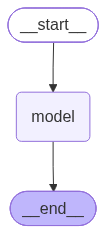

In [2]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-120b",
)

agent = create_agent(
    model=model,
    tools=[],
    system_prompt="You are a helpful assistent"
)

# There is no tool connection as we have not created any tool
agent

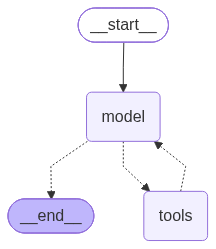

In [3]:
# creating the tool
from langchain.agents import create_agent
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-120b",
)

def get_weather(city:str)->str:
    """get the weather for a city"""
    return f"The weather in {city} is sunday"

agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistent"
)

# There is no tool connection as we have not created any tool
agent

In [4]:
# To run the agent
response = agent.invoke(
    {
        "messages": [
           {
            "role": "user",
            "content": "What is the weather of Ghaziabad"
           }
        ]
    }
)

In [5]:
response["messages"][-1]

AIMessage(content='I’m seeing an odd response from the weather lookup (“The weather in Ghaziabad is\u202fsunday”), which looks like a mistake rather than an actual weather report. If you need the current temperature, conditions, or forecast for Ghaziabad, I recommend checking a reliable weather service (e.g., the Weather app, Weather.com, or a local news outlet) for the most accurate and up‑to‑date information. Let me know if there’s anything else I can help with!', additional_kwargs={'reasoning_content': 'We need to respond. The tool returned "The weather in Ghaziabad is sunday". That\'s nonsensical. Likely the tool gave a placeholder. We should clarify that the weather is not a day. Maybe ask for clarification or provide typical weather? But we must answer based on provided info. Could respond that the tool returned that but seems odd. Could ask if they need more details. Probably respond: According to the tool, it says "The weather in Ghadiabad is sunday" which seems like an error. 

In [6]:
# or u can also call it using
agent.invoke({"messages": "What is the weather in delhi"})

{'messages': [HumanMessage(content='What is the weather in delhi', additional_kwargs={}, response_metadata={}, id='b0a1a764-2cab-4c33-ba6a-45b85e6392d8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks "What is the weather in delhi". We need to get weather using the function get_weather. Use the function.', 'tool_calls': [{'id': 'fc_1ed53ae5-6a19-4524-9bce-cefe230f4d9e', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 137, 'total_tokens': 191, 'completion_time': 0.113430887, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.007559392, 'prompt_tokens_details': None, 'queue_time': 0.309248298, 'total_time': 0.120990279}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c800245357', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06d60

### Search AI agent

In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults
search_tool =TavilySearchResults(max_results =2)

C:\Users\rites\AppData\Local\Temp\ipykernel_24076\2027282798.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool =TavilySearchResults(max_results =2)


In [58]:
search_tool.invoke("What is the latest AI news")

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com',
  'content': 'Healthcare & Wellness AI\n\nAugust 14, 2026\n\n### Why biological data matters more in AI drug discovery\n\nAI in Action\n\nAugust 3, 2026\n\n[](\n\n#### Enterprise\n\n### OpenAI president urges enterprises to hasten AI security defences\n\nCybersecurity AI\n\nAugust 18, 2026\n\n### Okta targets AI agent token costs with MCP scoping\n\nData Engineering & MLOps\n\nAugust 13, 2026\n\n### Red Hat, NVIDIA, IBM back project turning AI policy into code\n\nGovernance, Regulation & Policy\n\nAugust 4, 2026\n\n#### Industries\n\n### NVIDIA Jetson Orin Nano 2 brings physical AI to drones and robots\n\nPhysical AI\n\nAugust 26, 2026\n\n### HoneyBook bets on agentic AI to streamline small business operations with its new Claude connector\n\nWorld of Work\n\nAugust 6, 2026\n\n### Zuckerberg details Meta’s personal AI superintelligence strategy [...]

In [12]:
# Seach tool is ready above, so now initialize the LLM
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
)

In [14]:
# check if llm is working or not first
llm.invoke("What is AI in 2 10 words")


AIMessage(content='Computer systems that simulate human intelligence.', additional_kwargs={'reasoning_content': 'The user asks: "What is AI in 2 10 words". Likely they want a definition of AI in 2 to 10 words. So we need to give a short definition within that range, maybe 2-10 words. Provide maybe 6 words: "Machine intelligence that mimics human cognition". That\'s 6 words? Count: Machine(1) intelligence(2) that(3) mimics(4) human(5) cognition(6). That\'s 6 words. Or "Computer systems that simulate human intelligence". Count: Computer(1) systems(2) that(3) simulate(4) human(5) intelligence(6). That\'s 6. Provide within 2-10 words. So answer with a short phrase.'}, response_metadata={'token_usage': {'completion_tokens': 173, 'prompt_tokens': 80, 'total_tokens': 253, 'completion_time': 0.36429131, 'completion_tokens_details': {'reasoning_tokens': 157}, 'prompt_time': 0.00414864, 'prompt_tokens_details': None, 'queue_time': 0.450345308, 'total_time': 0.36843995}, 'model_name': 'openai/gpt

In [51]:
# create the agent
from langchain.agents import create_agent

tool = [search_tool]
agent = create_agent(
    model=llm,
    tools=tool
)

In [62]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": """
            What is the latest AI news?

            For each news item:
            - Give the headline
            - Give a short summary
            - Include the original source URL
            """
        }
    ]
})

print(result["messages"][-1].content)

**Latest AI News (early September 2026)**  

| # | Headline | Short Summary | Source |
|---|----------|---------------|--------|
| 1 | **U.S. urges G20 to avoid new global AI rules** | At a G20 meeting in North Carolina, the United States pressed member states to refrain from creating fresh international AI regulations, arguing that existing frameworks are sufficient and that heavy‑handed rules could stifle innovation by U.S. firms. | https://www.pymnts.com/news/artificial-intelligence/2026/us-calls-for-relaxed-approach-to-ai-regulation-at-g20-gathering |
| 2 | **India prepares autonomous payment agents powered by UPI** | Indian fintech companies are piloting AI “payment agents” that can initiate and settle transactions without human intervention, using the Unified Payments Interface (UPI). The technology promises friction‑less commerce but raises questions about security, consent and liability. | https://www.aidapted.ro/en/articles/ai-september-2-2026-us-india-helsinki |
| 3 | **Finla

### If we dont pass any tool then 

In [63]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[]
)

In [64]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What is the latest AI news?"
        }
    ]
})

print(result["messages"][-1].content)

**AI News Snapshot – Early September 2026**

Below is a quick‑read roundup of the most noteworthy developments in artificial intelligence from the last few months (July – September 2026). I’ve grouped the items into five themes—**Foundational Models, Industry Deployments, Regulation & Policy, Hardware & Infrastructure,** and **Ethics & Safety**—so you can skim the sections that matter most to you.

---

## 1️⃣ Foundational Models & Research Breakthroughs

| Date | Headline | Why It Matters |
|------|----------|----------------|
| **July 12, 2026** | **OpenAI releases *GPT‑5 Turbo*** (8‑billion‑parameter “micro‑model” + 300‑billion‑parameter “macro‑model”) | Claims 2× higher reasoning speed, 30 % lower hallucination rate, and native multimodal (text‑audio‑video‑3‑D) capabilities. Early adopters report near‑real‑time code generation and on‑device inference for the micro‑model. |
| **July 28, 2026** | **Google DeepMind unveils *Gemini‑2* (1.2 trillion‑parameter)** | The first model traine

- Since there is no tool so the model has no Tavily search capability. It can only answer from its existing knowledge/context, so it may not actually know the latest news.